# Pythia syntax-semantic norms

Quick visualization for the globally centered Pythia syntax-semantic norm-fraction runs using the full 2018-sample semantic set, filtered to the syntax-matched subset.

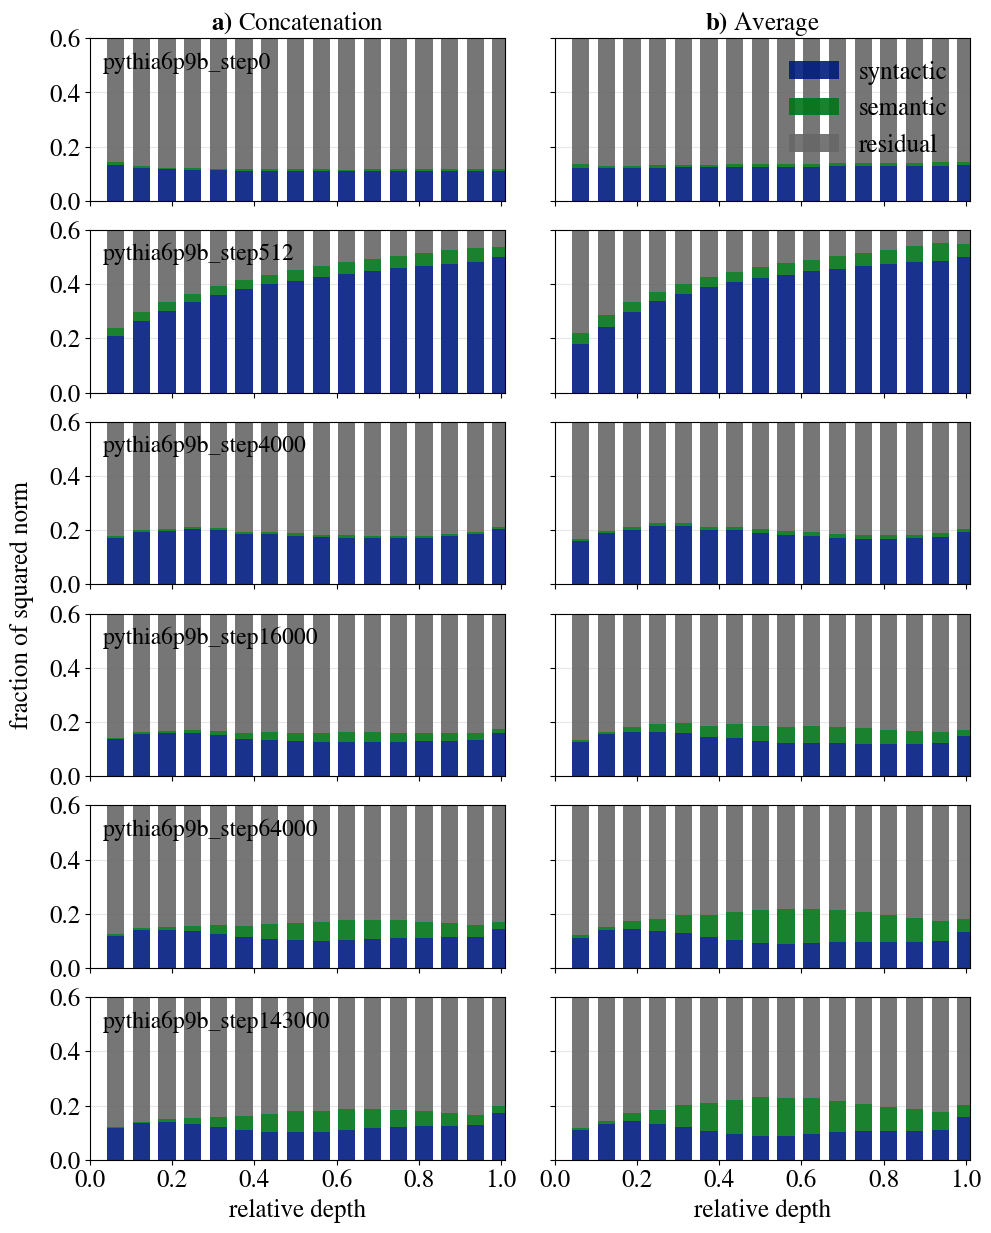

In [34]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

models = ['pythia6p9b_step0', 'pythia6p9b_step512', 'pythia6p9b_step4000', 'pythia6p9b_step16000', 'pythia6p9b_step64000', 'pythia6p9b_step143000']
min_token_length = 3
n_samples = 2018
global_center_flag = 1
configs = [0, 1]

def load_run(base, avg_tokens, n_tokens=None):
    root = base / f'avg_tokens_{avg_tokens}' / f'min_token_length_{min_token_length}' / f'n_samples_{n_samples}'
    if avg_tokens == 0 and n_tokens not in (None, min_token_length):
        root = root / f'n_tokens_{n_tokens}'
    root = root / 'norms' / f'global_center_flag_{global_center_flag}'
    path = root / 'norms.npz'
    meta_path = root / 'metadata.json'
    if not path.exists():
        return None
    metadata = {}
    if meta_path.exists():
        import json
        metadata = json.loads(meta_path.read_text())
    return path, np.load(path), metadata

rcpsize = 18
plt.rcParams['xtick.labelsize'] = rcpsize
plt.rcParams['ytick.labelsize'] = rcpsize
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams['font.size'] = rcpsize
plt.rcParams.update({'figure.autolayout': False})

colors = plt.style.library['seaborn-v0_8-dark-palette']['axes.prop_cycle'].by_key()['color']
syn_color = colors[0]
sem_color = colors[1]
residual_color = '#676767'

bar_width = 0.042
panel_labels = {0: r'$\mathbf{a)}$ Concatenation', 1: r'$\mathbf{b)}$ Average'}

fig, axes = plt.subplots(len(models), 2, figsize=(10, 2.1 * len(models)), sharex=True, sharey=True)

for row, model in enumerate(models):
    base = Path(f'/home/acevedo/syn-sem/pythia/results/model_{model}')
    runs = {avg_tokens: load_run(base, avg_tokens) for avg_tokens in configs}

    for col, avg_tokens in enumerate(configs):
        ax = axes[row, col]
        run = runs[avg_tokens]
        if run is None:
            ax.text(0.5, 0.5, f'avg_tokens={avg_tokens} missing', ha='center', va='center', transform=ax.transAxes)
            ax.set_axis_off()
            continue

        _, data, metadata = run
        rel_depths = data['rel_depths']
        syn_means = data['syn_means']
        sem_means = data['sem_means']
        residual_means = data['residual_means']

        x = np.linspace(1 / len(rel_depths), 1, len(rel_depths))
        ax.bar(x, syn_means, width=bar_width, color=syn_color, label='syntactic', alpha=0.9)
        ax.bar(x, sem_means, width=bar_width, bottom=syn_means, color=sem_color, label='semantic', alpha=0.9)
        ax.bar(x, residual_means, width=bar_width, bottom=syn_means + sem_means, color=residual_color, label='residual', alpha=0.9)
        ax.set_xlim(0.03, 1.01)
        ax.set_ylim(0.0, 0.6)
        ax.set_xticks(np.linspace(0.0, 1.0, 6))
        ax.set_xticklabels([f'{tick:.1f}' for tick in np.linspace(0.0, 1.0, 6)])
        ax.grid(axis='y', alpha=0.3)
        ax.set_axisbelow(True)
        if row == 0:
            ax.set_title(panel_labels[avg_tokens], fontsize=rcpsize)
        if row == len(models) - 1:
            ax.set_xlabel('relative depth', fontsize=rcpsize)
        if col == 0:
            ax.text(0.03, 0.92, model, ha='left', va='top', transform=ax.transAxes, fontsize=rcpsize - 1)

axes[0, 1].legend(loc='upper right', frameon=False)
fig.text(0.02, 0.5, 'fraction of squared norm', va='center', rotation='vertical', fontsize=rcpsize)
plt.subplots_adjust(hspace=0.18, wspace=0.12, left=0.10, right=0.98, top=0.95, bottom=0.06)

fig_dir = Path('/home/acevedo/syn-sem/pythia/results/figs')
fig_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(fig_dir / 'pythia6p9b_all_checkpoints_syn_sem_norms_global_centered_n2018.pdf', bbox_inches='tight')
plt.show()

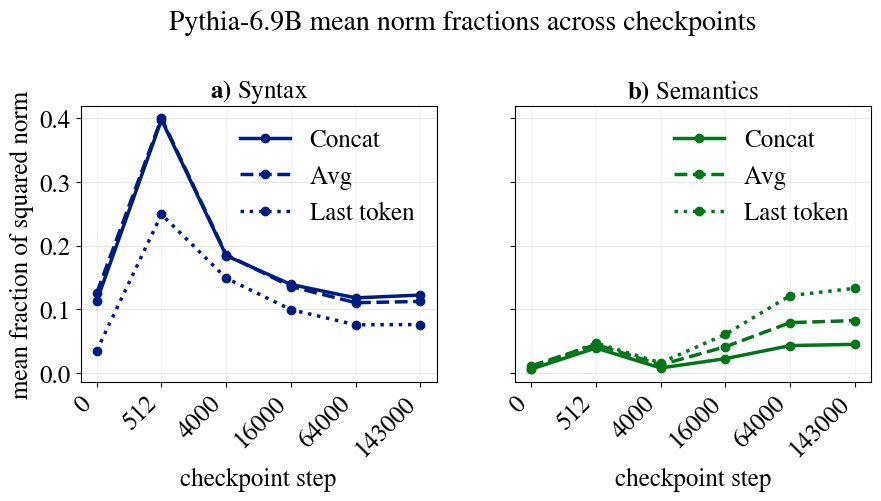

In [35]:
checkpoint_steps = []
series_configs = [('Concat', 0, None), ('Avg', 1, None), ('Last token', 0, 1)]
evolution = {label: {'syn': [], 'sem': []} for label, _, _ in series_configs}

for model in models:
    step = int(model.split('step')[-1])
    base = Path(f'/home/acevedo/syn-sem/pythia/results/model_{model}')
    runs = {label: load_run(base, avg_tokens, n_tokens=n_tokens) for label, avg_tokens, n_tokens in series_configs}
    if any(run is None for run in runs.values()):
        print(f'skipping {model}: missing norms output')
        continue

    checkpoint_steps.append(step)
    for label, _, _ in series_configs:
        _, data, _ = runs[label]
        evolution[label]['syn'].append(float(np.mean(data['syn_means'])))
        evolution[label]['sem'].append(float(np.mean(data['sem_means'])))

fig, axes = plt.subplots(1, 2, figsize=(10.2, 4.6), sharex=True, sharey=True)
plot_x = np.arange(len(checkpoint_steps))
linestyles = {'Concat': '-', 'Avg': '--', 'Last token': ':'}
panel_meta = [('syn', syn_color, r'$\mathbf{a)}$ Syntax'), ('sem', sem_color, r'$\mathbf{b)}$ Semantics')]

for ax, (key, color, title) in zip(axes, panel_meta):
    for label, _, _ in series_configs:
        vals = evolution[label][key]
        ax.plot(
            plot_x,
            vals,
            marker='o',
            linewidth=2.5,
            linestyle=linestyles[label],
            color=color,
            label=label,
        )
    ax.set_title(title, fontsize=rcpsize)
    ax.set_xticks(plot_x)
    ax.set_xticklabels([str(step) for step in checkpoint_steps], rotation=45, ha='right')
    ax.grid(axis='y', alpha=0.3)
    ax.grid(axis='x', alpha=0.15)
    ax.set_axisbelow(True)
    ax.set_xlabel('checkpoint step', fontsize=rcpsize)
    ax.legend(loc='upper right', frameon=False)

axes[0].set_ylabel('mean fraction of squared norm', fontsize=rcpsize)
fig.suptitle('Pythia-6.9B mean norm fractions across checkpoints', fontsize=rcpsize + 2, y=1.03)
plt.subplots_adjust(wspace=0.22, top=0.82, bottom=0.22)

fig_dir = Path('/home/acevedo/syn-sem/pythia/results/figs')
fig_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(fig_dir / 'pythia6p9b_norms_checkpoint_evolution_n2018.pdf', bbox_inches='tight')
plt.show()

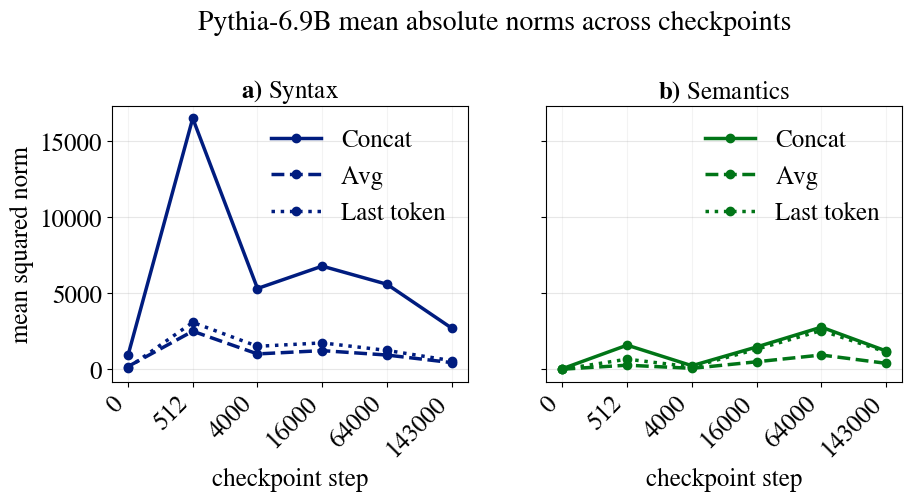

In [36]:
checkpoint_steps_abs = []
evolution_abs = {label: {'syn': [], 'sem': []} for label, _, _ in series_configs}

for model in models:
    step = int(model.split('step')[-1])
    base = Path(f'/home/acevedo/syn-sem/pythia/results/model_{model}')
    runs = {label: load_run(base, avg_tokens, n_tokens=n_tokens) for label, avg_tokens, n_tokens in series_configs}
    if any(run is None for run in runs.values()):
        print(f'skipping {model}: missing norms output')
        continue

    checkpoint_steps_abs.append(step)
    for label, _, _ in series_configs:
        _, data, _ = runs[label]
        evolution_abs[label]['syn'].append(float(np.mean(data['syn_abs_means'])))
        evolution_abs[label]['sem'].append(float(np.mean(data['sem_abs_means'])))

fig, axes = plt.subplots(1, 2, figsize=(10.2, 4.6), sharex=True, sharey=True)
plot_x = np.arange(len(checkpoint_steps_abs))

for ax, (key, color, title) in zip(axes, panel_meta):
    for label, _, _ in series_configs:
        vals = evolution_abs[label][key]
        ax.plot(
            plot_x,
            vals,
            marker='o',
            linewidth=2.5,
            linestyle=linestyles[label],
            color=color,
            label=label,
        )
    ax.set_title(title, fontsize=rcpsize)
    ax.set_xticks(plot_x)
    ax.set_xticklabels([str(step) for step in checkpoint_steps_abs], rotation=45, ha='right')
    ax.grid(axis='y', alpha=0.3)
    ax.grid(axis='x', alpha=0.15)
    ax.set_axisbelow(True)
    ax.set_xlabel('checkpoint step', fontsize=rcpsize)
    ax.legend(loc='upper right', frameon=False)

axes[0].set_ylabel('mean squared norm', fontsize=rcpsize)
fig.suptitle('Pythia-6.9B mean absolute norms across checkpoints', fontsize=rcpsize + 2, y=1.03)
plt.subplots_adjust(wspace=0.22, top=0.82, bottom=0.22)

fig_dir = Path('/home/acevedo/syn-sem/pythia/results/figs')
fig_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(fig_dir / 'pythia6p9b_absolute_norms_checkpoint_evolution_n2018.pdf', bbox_inches='tight')
plt.show()

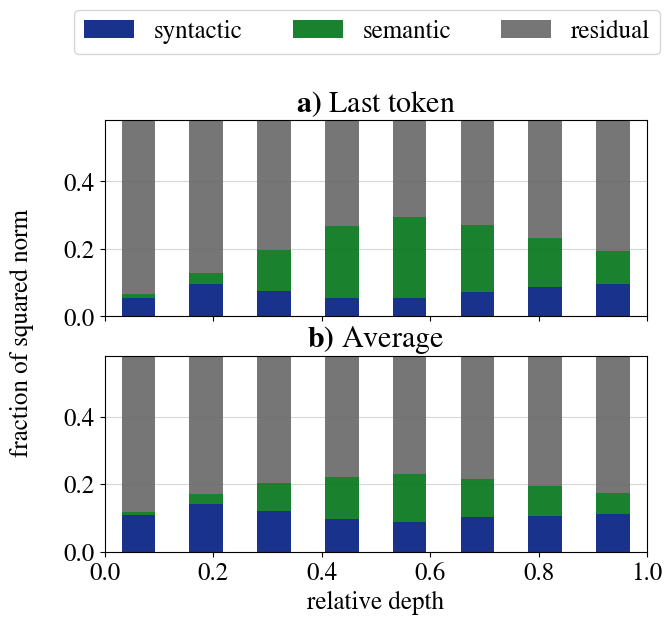

In [37]:
last_token_n_tokens = 1
fig, axes = plt.subplots(2, 1, figsize=(7, 5.6), sharex=True, sharey=True, gridspec_kw={'hspace': 0.20})

for i, avg_tokens in enumerate(configs):
    ax = axes[i]
    run_n_tokens = last_token_n_tokens if avg_tokens == 0 else None
    run = load_run(Path('/home/acevedo/syn-sem/pythia/results/model_pythia6p9b_step143000'), avg_tokens, n_tokens=run_n_tokens)
    if run is None:
        ax.text(0.5, 0.5, 'missing last-token norms output', ha='center', va='center', transform=ax.transAxes)
        ax.set_axis_off()
        continue

    _, data, _ = run
    rel_depths = data['rel_depths']
    syn_means = data['syn_means']
    sem_means = data['sem_means']
    residual_means = data['residual_means']

    bar_width = 0.062
    n_layers = len(rel_depths)
    x = np.linspace(1 / n_layers, 1, n_layers)
    idx = np.arange(n_layers)
    mask = idx % 2 == 0
    x = x[mask]
    syn_means = syn_means[mask]
    sem_means = sem_means[mask]
    residual_means = residual_means[mask]

    ax.bar(x, syn_means, width=bar_width, label='syntactic', color=syn_color, alpha=0.9)
    ax.bar(x, sem_means, width=bar_width, bottom=syn_means, label='semantic', color=sem_color, alpha=0.9)
    ax.bar(x, residual_means, width=bar_width, bottom=syn_means + sem_means, label='residual', color=residual_color, alpha=0.9)
    ax.set_xlim(0.01, 0.99)
    ax.set_ylim(0, 0.58)
    ax.grid(True, axis='y', alpha=0.5)
    ax.set_axisbelow(True)
    title = r'$\mathbf{a)}$ Last token' if avg_tokens == 0 else r'$\mathbf{b)}$ Average'
    ax.set_title(title)

axes[-1].set_xticks(np.linspace(0, 1, 6))
axes[-1].set_xticklabels([f'{t:.1f}' for t in np.linspace(0, 1, 6)])
axes[-1].set_xlabel('relative depth', fontsize=rcpsize)
fig.supylabel('fraction of squared norm', fontsize=rcpsize, x=-0.01)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.1))

fig_dir = Path('/home/acevedo/syn-sem/pythia/results/figs')
fig_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(fig_dir / 'pythia6p9b_last_token_norms_bars_vertical_n2018.pdf', bbox_inches='tight')
plt.show()